#  **Titanic Survival Prediction**
## **Model Development Notebook**

---

##  **Introduction**

The Titanic disaster is one of the most well-known maritime tragedies in history. Machine learning provides a way to analyze passenger data and build predictive models that estimate the probability of survival based on personal and travel-related attributes.

This notebook focuses on building a **Titanic Survival Prediction Model** using a **Support Vector Machine (SVM)** classifier combined with a **scikit-learn Pipeline**. The pipeline ensures that preprocessing and model training are treated as one unified system, making deployment simple and reliable.

---

##  **Objective of the Task**

The main objective of this project is to:

- Build a machine learning model that predicts whether a passenger survived the Titanic disaster.
- Use only five selected features as inputs.
- Apply proper preprocessing techniques.
- Use an SVM classifier for prediction.
- Combine preprocessing and model training into a single pipeline.
- Save only one trained model object for deployment.

---

##  **Tasks to Be Performed**

1. Load the Titanic dataset.
2. Select the required features and target variable.
3. Handle missing values.
4. Prepare numerical and categorical preprocessing steps.
5. Build an SVM model using a Pipeline.
6. Split data into training and testing sets.
7. Train the model.
8. Evaluate model performance.
9. Save the trained pipeline.
10. Reload the pipeline and test prediction.

---

##  **Metadata**

- Dataset: Titanic – Machine Learning from Disaster
- Algorithm: Support Vector Machine (SVM)
- Framework: Scikit-learn
- Programming Language: Python
- Features Used: 5
- Target Variable: Survived (0 = Did not survive, 1 = Survived)
- Output Type: Binary Classification

---

##  Description of Selected Features

The following five features are used as input variables:

1. **Pclass**: Passenger class (1 = First class, 2 = Second class, 3 = Third class)
2. **Sex**: Gender of the passenger (male or female)
3. **Age**: Age of the passenger in years
4. **Fare**: Amount of money paid for the ticket
5. **Embarked**: Port of embarkation
   - C = Cherbourg
   - Q = Queenstown
   - S = Southampton

Target variable:

- **Survived**: Indicates whether the passenger survived
  - 0 = Did not survive
  - 1 = Survived

---

## **Import Required Libraries**

We begin by importing all the necessary libraries for data handling, preprocessing, modeling, evaluation, and saving the model.

```python


In [1]:
#Importing Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

We load the Titanic dataset from a CSV file into a pandas DataFrame.



In [2]:
df = pd.read_csv("../data/titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **Select Required Columns**

We keep only the five selected features and the target variable.


In [3]:
# Selecting features and target variable
features = ["Pclass", "Sex", "Age", "Fare", "Embarked"]
target = "Survived"

# Keep only selected columns
df = df[features + [target]]
df.head()


,Pclass,Sex,Age,Fare,Embarked,Survived
0,3,male,22.0,7.2500,S,0
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,1
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0


## Check Missing Values and Handle Missing Values

Before modeling, we check for missing values in the dataset. We fill missing values using simple statistical strategies:

- Age: Replace with median age.
- Embarked: Replace with most frequent category (mode).



In [4]:
df.isnull().sum()

# Handling missing values

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Confirm no missing values remain
df.isnull().sum()



Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
Survived    0
dtype: int64

## **Separate Features and Target**

We separate input variables (X) from the target variable (y).


In [5]:
X = df[features]
y = df[target]


## **Define Preprocessing Steps**

We handle different data types differently:

- Numerical features are scaled using StandardScaler.
- Categorical features are encoded using OneHotEncoder.


In [6]:
numeric_features = ["Pclass", "Age", "Fare"]
categorical_features = ["Sex", "Embarked"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## **Build Pipeline with SVM**

The pipeline links preprocessing and model training into one object.



In [7]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", SVC(kernel="rbf"))
])

## **Train-Test Split**

We split the dataset into training and testing sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train the Model

We train the entire pipeline using the training data.

In [9]:
# Fit the pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pclass', 'Age', 'Fare']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked'])])),
                ('model', SVC())])

## **Evaluate the Model**

We evaluate model performance using accuracy and classification report.



In [10]:
# Make predictions
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179




## **Confusion Matrix**

We display a confusion matrix to understand prediction errors.


In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[95, 10],
       [25, 49]])

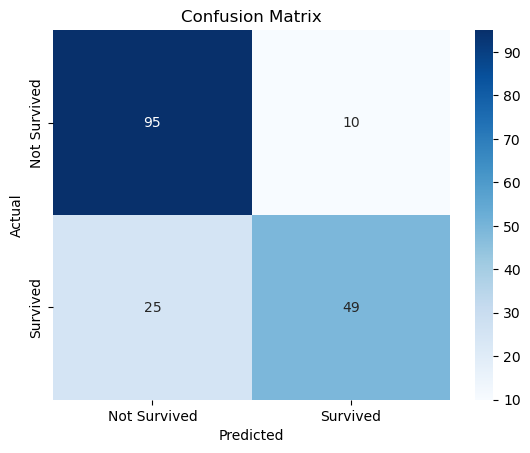

In [12]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **Save the Entire Pipeline**

We save the pipeline as one file, which includes preprocessing and the model.



In [13]:
# Save the trained pipeline
joblib.dump(pipeline, "titanic_survival_model.pkl")
print("Pipeline saved successfully.")



Pipeline saved successfully.


## **Reload and Test Without Retraining**

We reload the saved pipeline and test it on a sample input.

In [14]:
# Load the saved pipeline and make a prediction
# Reload saved pipeline
loaded_pipeline = joblib.load("titanic_survival_model.pkl")

# Take a sample from test set
sample = X_test.iloc[[42]]

# Make prediction
pred = loaded_pipeline.predict(sample)[0]
actual = y_test.iloc[42]

# Map numbers to labels
pred_text = "Survived" if pred == 1 else "Did Not Survive"
actual_text = "Survived" if actual == 1 else "Did Not Survive"

# Display results
print("Prediction:", pred, "→", pred_text)
print("Actual:", actual, "→", actual_text)



Prediction: 0 → Did Not Survive
Actual: 0 → Did Not Survive
